In [36]:
from IPython.display import display, HTML

display(HTML("""
<style>

/* =========================
   전체 레이아웃
========================= */

div.container{
    width:85% !important;
}

div.cell.code_cell.rendered{
    width:100%;
}

div.input_prompt{
    padding:0;
}

div.prompt{
    min-width:70px;
}

div#toc-wrapper{
    padding-top:120px;
}

table.dataframe{
    font-size:12px;
}

/* =========================
   코드 입력창
========================= */

div.CodeMirror{
    font-family:"마루 부리OTF 중간" !important;
    font-size:12pt !important;
    line-height:1.6;
}

/* =========================
   입력 셀
========================= */

div.input{
    font-family:"마루 부리OTF 중간" !important;
    font-size:12pt !important;
}

/* =========================
   코드 출력
========================= */

div.output{
    font-family:"마루 부리OTF 중간" !important;
    font-size:12pt !important;
}

/* =========================
   Markdown 전체
========================= */

.rendered_html{
    font-family:"마루 부리OTF 중간" !important;
    font-size:18px !important;
    line-height:1.8;
}

/* 제목 */
.rendered_html h1,
.rendered_html h2,
.rendered_html h3,
.rendered_html h4,
.rendered_html h5,
.rendered_html h6{
    font-family:"마루 부리OTF 조금굵은" !important;
}

/* 본문 */
.rendered_html p{
    font-family:"마루 부리OTF 중간" !important;
}

/* 리스트 */
.rendered_html li{
    font-family:"마루 부리OTF 중간" !important;
    padding:5px;
}

/* 인용 */
.rendered_html blockquote{
    font-family:"마루 부리OTF 중간" !important;
}

/* 표 */
.rendered_html table{
    font-family:"마루 부리OTF 중간" !important;
}

/* 코드 블록 */
.rendered_html pre,
.rendered_html code{
    font-family:"Consolas" !important;
    font-size:12pt !important;
}

</style>
"""))


# 1. 데이터 생성
- 남여 키와 몸무게 데이터를 군집화

In [10]:
import random
import numpy as np
import matplotlib.pyplot as plt

In [11]:
random.randint(140, 195)

154

In [12]:
data = []
for i in range(50):
    # 여자 데이터(몸무게와 키) 추가
    data.append([random.randint(40, 70), random.randint(140, 170)])
    # 남자 데이터(몸무게와 키) 추가
    data.append([random.randint(60, 95), random.randint(160, 195)])

In [13]:
print('여자 몸무게(x축) :', [female[0] for female in data[::2]])
print('여자 키(y축) :', [female[1] for female in data[::2]])
print( )
print('남자 몸무게(x축) :', [male[0] for male in data[1::2]])
print('남자 키(y축) :', [male[1] for male in data[1::2]])

여자 몸무게(x축) : [48, 53, 69, 40, 44, 40, 45, 56, 56, 56, 54, 64, 60, 69, 40, 56, 60, 48, 50, 68, 70, 46, 60, 49, 41, 48, 64, 46, 67, 52, 48, 70, 65, 49, 61, 50, 70, 52, 64, 68, 68, 64, 47, 55, 69, 66, 42, 44, 43, 51]
여자 키(y축) : [155, 163, 143, 165, 154, 158, 169, 152, 156, 148, 156, 155, 157, 159, 156, 160, 142, 144, 157, 167, 166, 166, 155, 152, 161, 152, 148, 160, 161, 170, 143, 156, 156, 141, 141, 165, 162, 158, 148, 161, 155, 163, 164, 143, 147, 166, 149, 141, 145, 164]

남자 몸무게(x축) : [82, 70, 94, 87, 87, 89, 63, 80, 84, 91, 71, 83, 60, 89, 91, 66, 68, 81, 64, 89, 82, 62, 73, 64, 87, 78, 84, 72, 75, 83, 60, 69, 64, 88, 94, 61, 69, 91, 62, 86, 85, 83, 95, 89, 73, 77, 85, 68, 84, 94]
남자 키(y축) : [187, 177, 187, 195, 163, 187, 176, 186, 164, 185, 175, 188, 166, 188, 185, 178, 176, 178, 171, 185, 175, 168, 169, 189, 168, 178, 186, 185, 193, 167, 175, 161, 171, 177, 167, 175, 190, 169, 186, 193, 179, 162, 170, 173, 171, 164, 179, 189, 178, 194]


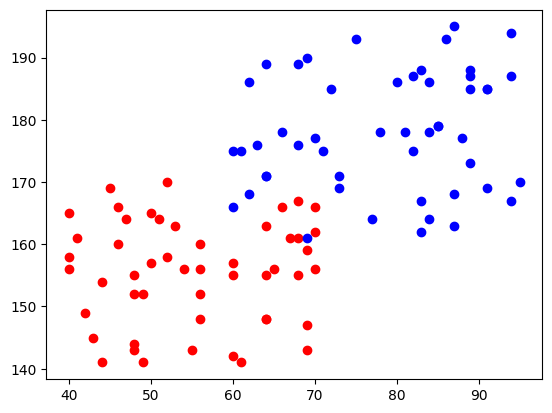

In [14]:
plt.plot([female[0] for female in data[::2]],
         [female[1] for female in data[::2]], 'o', color='r')
plt.plot([male[0] for male in data[1::2]],
        [male[1] for male in data[1::2]], 'o', color='b')
plt.show()

# 2. 군집화 로직

In [15]:
# 초기 랜덤 지점 2개
random_poinsts = [
    [random.randint(40,90), random.randint(140,195)],
    [random.randint(40,90), random.randint(140,195)]
]
random_poinsts[0], random_poinsts[1]

([69, 186], [90, 165])

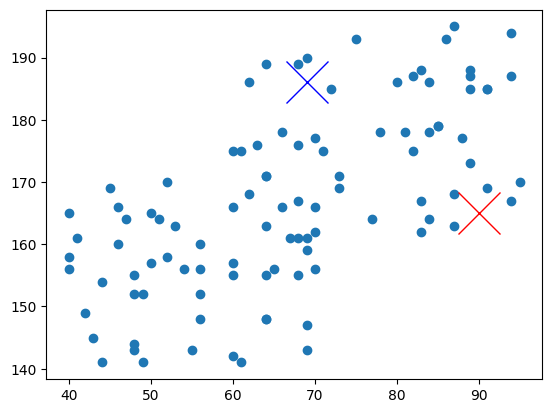

In [16]:
plt.plot([d[0] for d in data],
         [d[1] for d in data], 'o')
plt.plot(random_poinsts[0][0], random_poinsts[0][1], 'x', markersize=30, color='b') # 기준점0
plt.plot(random_poinsts[1][0], random_poinsts[1][1], 'x', markersize=30, color='r') # 기준점1

In [17]:
# 두점 거리를 return하는 함수 점은 [50,160]
def dist(a, b):
    return np.sqrt( (a[0]-b[0])**2 + (a[1]-b[1])**2 )
print(dist([3,4], [0,0]))
print(dist([5,7], [-1,-1]))

5.0
10.0


In [18]:
# random_points[0]에 가까운 그룹(group0)과 random_points[1]에 가까운 그룹(group1)을 분류
group0 = []
group1 = []
for d in data:
    if dist(random_poinsts[0], d) < dist(random_poinsts[1], d):
        group0.append(d)
    else:
        group1.append(d)
len(group0), len(group1)

(57, 43)

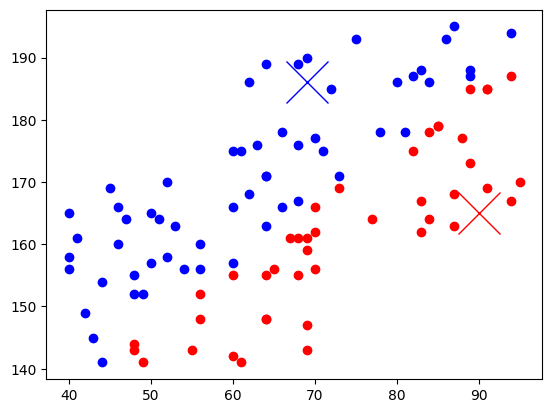

In [19]:
# group0과 group1, random_points[0]과 random_points[1]
plt.plot([d[0] for d in group0], [d[1] for d in group0], 'o', color='b')
plt.plot([d[0] for d in group1], [d[1] for d in group1], 'o', color='r')
plt.plot(random_poinsts[0][0], random_poinsts[0][1], 'x', markersize=30, color='b')
plt.plot(random_poinsts[1][0], random_poinsts[1][1], 'x', markersize=30, color='r')
plt.show()

In [20]:
# group0과 group1 중심점으로 기준점을 이동
group0_meanX = np.mean([d[0] for d in group0])
group0_meanY = np.mean([d[1] for d in group0])
random_poinsts[0] = [group0_meanX, group0_meanY]

group1_meanX = np.mean([d[0] for d in group1])
group1_meanY = np.mean([d[1] for d in group1])
random_poinsts[1] = [group1_meanX, group1_meanY]
random_poinsts

[[61.75438596491228, 170.52631578947367],
 [73.74418604651163, 161.69767441860466]]

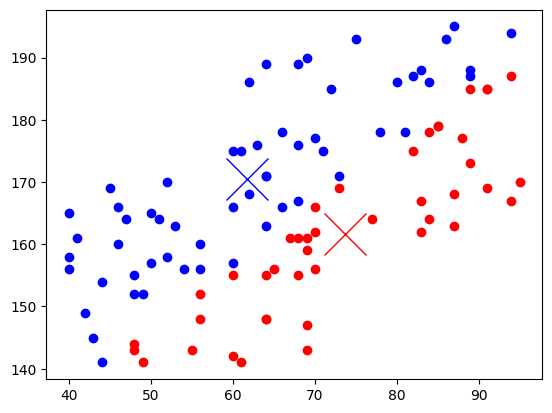

In [21]:
plt.plot([d[0] for d in group0], [d[1] for d in group0], 'o', color='b')
plt.plot([d[0] for d in group1], [d[1] for d in group1], 'o', color='r')
plt.plot(random_poinsts[0][0], random_poinsts[0][1], 'x', markersize=30, color='b')
plt.plot(random_poinsts[1][0], random_poinsts[1][1], 'x', markersize=30, color='r')
plt.show()

# 3. 군집화 전체 코드 (for문 이용)
- 랜덤포인트 2개 지정 - 출력 및 시각화
- for문
    * 랜덤포인트 2지점 기준으로 group0과 group1을 나눔
    * group1의 중간점과 group1의 중간지점을 랜덤포인트로 업데이트
    * 랜덤 포인트 출력 및 시각화

초기 지점 : [[93, 163], [51, 183]]
1 번째 points : [[79.27083333333333, 169.95833333333334], [55.5, 163.75]]
2 번째 points : [[80.84444444444445, 177.88888888888889], [55.50909090909091, 157.6]]
3 번째 points : [[80.81818181818181, 179.02272727272728], [55.982142857142854, 157.07142857142858]]
4 번째 points : [[81.06976744186046, 179.32558139534885], [56.228070175438596, 157.2280701754386]]
5 번째 points : [[81.06976744186046, 179.32558139534885], [56.228070175438596, 157.2280701754386]]
6 번째 points : [[81.06976744186046, 179.32558139534885], [56.228070175438596, 157.2280701754386]]
7 번째 points : [[81.06976744186046, 179.32558139534885], [56.228070175438596, 157.2280701754386]]
8 번째 points : [[81.06976744186046, 179.32558139534885], [56.228070175438596, 157.2280701754386]]
9 번째 points : [[81.06976744186046, 179.32558139534885], [56.228070175438596, 157.2280701754386]]
10 번째 points : [[81.06976744186046, 179.32558139534885], [56.228070175438596, 157.2280701754386]]


(140.0, 195.0)

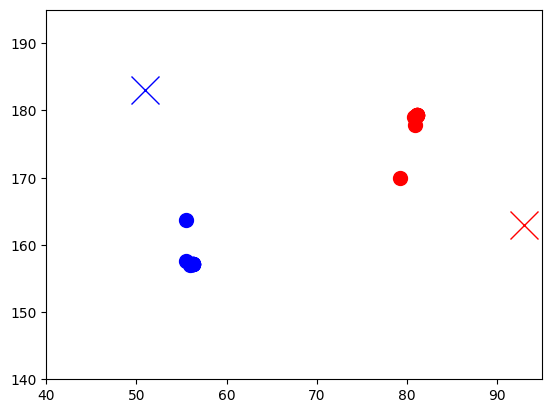

In [22]:
points = [
    [random.randint(40, 95), random.randint(140, 195)],
    [random.randint(40, 95), random.randint(140, 195)],
]
print('초기 지점 :', points)
plt.plot(points[0][0], points[0][1], 'x', color='r', markersize=20)
plt.plot(points[1][0], points[1][1], 'x', color='b', markersize=20)

for i in range(1, 11):
    # points 두 지점을 기준으로 group0과 group1 나누기
    group0 = []
    group1 = []
    for info in data:
        if dist(points[0], info) < dist(points[1], info):
            group0.append(info)
        else:
            group1.append(info)
    
    # group0의 중간점, group1의 중간점으로 points 업데이트
    group0_meanX = np.mean([g[0] for g in group0])
    group0_meanY = np.mean([g[1] for g in group0])
    points[0] = [group0_meanX, group0_meanY]
    
    group1_meanX = np.mean([g[0] for g in group1])
    group1_meanY = np.mean([g[1] for g in group1])
    points[1] = [group1_meanX, group1_meanY]
    
    # 업데이트된 points 출력 및 시각화
    print(i, '번째 points :', points)
    plt.plot(points[0][0], points[0][1], 'o', color='r', markersize=10)
    plt.plot(points[1][0], points[1][1], 'o', color='b', markersize=10)
plt.xlim([40,95])
plt.ylim([140, 195])

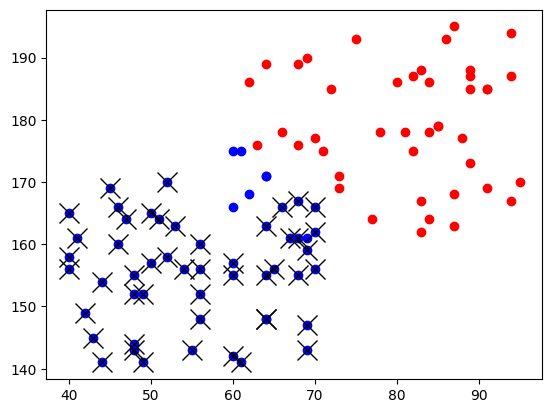

In [23]:
plt.plot([g[0] for g in group0],
             [g[1] for g in group0], 'o', color='r')
plt.plot([g[0] for g in group1],
             [g[1] for g in group1], 'o', color='b')
plt.plot(
    [female[0] for female in data[::2]],
    [female[1] for female in data[::2]], 'x', color='k', markersize=15)

# 4. api(sklearn)를 이용한 군집화
- sklearn : 머신러닝 패키지
    * 예측 모델 : 회귀분석, 분류분석
    * 군집 모델 : 군집분석
    * 예측/군집 모델 : fit(학습), predict(예측,분류)
    
    * 변환 모델 : 전처리에 사용 (ex. 인코딩, 스케일조정... - fit(학습), transform(변환함수), fit_transform(학변) )

In [28]:
# import os
# os.environ['OMP_NUM_THREADS'] = '1'
# import warnings
# warnings.filterwarnings(action='ignore') # 경고 무시

In [27]:
from sklearn.cluster import KMeans

data = np.array(data) # 원칙적으로 머신러닝 모델에는 넘파이 배열로 학습.

model = KMeans(n_clusters=2,         # 2개 그룹으로 군집화
                              init='random',      # 초기포인트를 랜덤하게
                              n_init=10,             # 10번 실행
                              random_state=7) # 일관적인 모델을 생성하기 위한 seed값

model.fit(data)

C:\Users\mbc1\anaconda3\envs\ml-dl-nlp\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,n_clusters,2
,init,'random'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,7
,copy_x,True
,algorithm,'lloyd'


In [29]:
# 두 그룹의 기준점:[55.17857142857143, 156.69642857142858], [79.02272727272727, 180.5]
model.cluster_centers_

array([[ 81.06976744, 179.3255814 ],
       [ 56.22807018, 157.22807018]])

In [30]:
# 나눠진 그룹들의 인덱스
model.labels_

array([1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0])

In [33]:
group1 = data[model.labels_==1]
group0 = data[model.labels_==0]

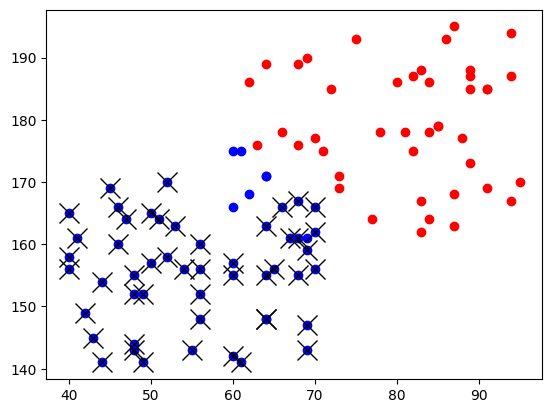

In [34]:
plt.plot([g[0] for g in group0],
             [g[1] for g in group0], 'o', color='r')
plt.plot([g[0] for g in group1],
             [g[1] for g in group1], 'o', color='b')
plt.plot(
    [female[0] for female in data[::2]],
    [female[1] for female in data[::2]], 'x', color='k', markersize=15)
plt.show()